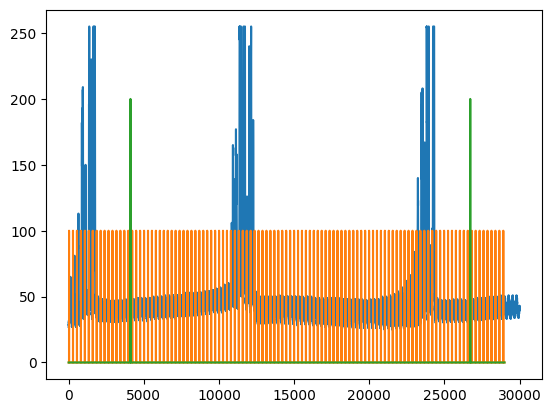

In [200]:
import numpy as np
import pylab as pl

# Load the file
data = np.load("raw2.npy")

# Slice back into your variables
raw_x = np.float64(data[:, 0])
raw_y = np.float64(data[:, 1])
raw_z = np.float64(data[:, 2])

pl.plot(raw_z)

window_size = 1000
smooth_x = np.convolve(raw_x, np.ones(window_size)/window_size, mode='valid')
pl.plot(100* (np.gradient(np.float64(smooth_x>10))>0))

window_size = 1000
smooth_y = np.convolve(raw_y, np.ones(window_size)/window_size, mode='valid')
pl.plot(200* (np.gradient(np.float64(smooth_y>180))<0))

# pl.xlim([10000,15000])

In [116]:
np.where((np.gradient(np.float64(smooth_y>180))<0))
#4113 # frame begin
#26718 # frame end

(array([ 4113,  4114, 26718, 26719]),)

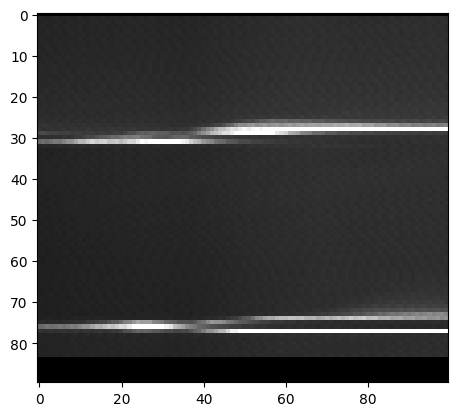

In [210]:
shift = 0

image = np.zeros((90,100))
counter = 1
next_allowed = 1
candidates = np.where(np.gradient(np.float64(smooth_x>10)))[0]
for idx, timestamp in enumerate(candidates):
    if (timestamp>4200) & (timestamp < 26000):
        if timestamp > next_allowed:
            next_allowed = timestamp + 200
            image[counter,:] = raw_z[timestamp+shift:(timestamp+100+shift)]
            counter = counter + 1;

pl.figure(1)
pl.imshow(image, aspect='equal',cmap = 'gray')